### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [13]:
import pandas as pd
import numpy as np

def ingreso_total(df: pd.DataFrame) -> float:
    precios = pd.to_numeric(df["Precio"], errors="coerce")
    return float(np.nansum(precios))

ingresos = {
    "Tienda 1": ingreso_total(tienda),
    "Tienda 2": ingreso_total(tienda2),
    "Tienda 3": ingreso_total(tienda3),
    "Tienda 4": ingreso_total(tienda4)
}

ingresos_df = pd.DataFrame(list(ingresos.items()), columns=["Tienda", "Ingreso Total"]).sort_values("Ingreso Total", ascending=False)

pd.options.display.float_format = "{:,.0f}".format
ingresos_df



,Tienda,Ingreso Total
0,Tienda 1,"1,150,880,400"
1,Tienda 2,"1,116,343,500"
2,Tienda 3,"1,098,019,600"
3,Tienda 4,"1,038,375,700"


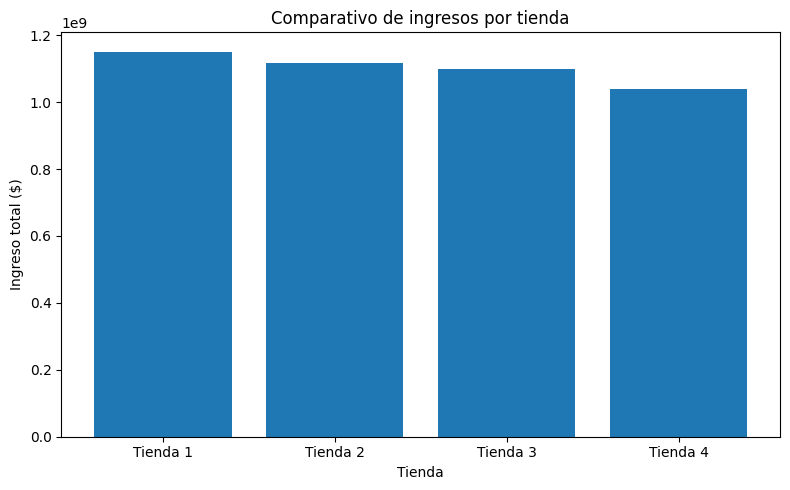

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(ingresos_df["Tienda"], ingresos_df["Ingreso Total"])
plt.title("Comparativo de ingresos por tienda")
plt.xlabel("Tienda")
plt.ylabel("Ingreso total ($)")
plt.tight_layout()
plt.show()


# 2. Ventas por categoría

In [15]:
import pandas as pd

tienda1 = tienda.copy()
tienda1["Tienda"] = "Tienda 1"

tienda2 = tienda2.copy()
tienda2["Tienda"] = "Tienda 2"

tienda3 = tienda3.copy()
tienda3["Tienda"] = "Tienda 3"

tienda4 = tienda4.copy()
tienda4["Tienda"] = "Tienda 4"

todas_tiendas = pd.concat([tienda1, tienda2, tienda3, tienda4], ignore_index=True)

ventas_categoria = (
    todas_tiendas.groupby(["Tienda", "Categoría del Producto"])
    .size()
    .reset_index(name="Cantidad de ventas")
)

pd.options.display.float_format = "{:,.0f}".format
ventas_categoria.head(10)



,Tienda,Categoría del Producto,Cantidad de ventas
0,Tienda 1,Artículos para el hogar,171
1,Tienda 1,Deportes y diversión,284
2,Tienda 1,Electrodomésticos,312
3,Tienda 1,Electrónicos,448
4,Tienda 1,Instrumentos musicales,182
5,Tienda 1,Juguetes,324
6,Tienda 1,Libros,173
7,Tienda 1,Muebles,465
8,Tienda 2,Artículos para el hogar,181
9,Tienda 2,Deportes y diversión,275


<Figure size 1000x600 with 0 Axes>

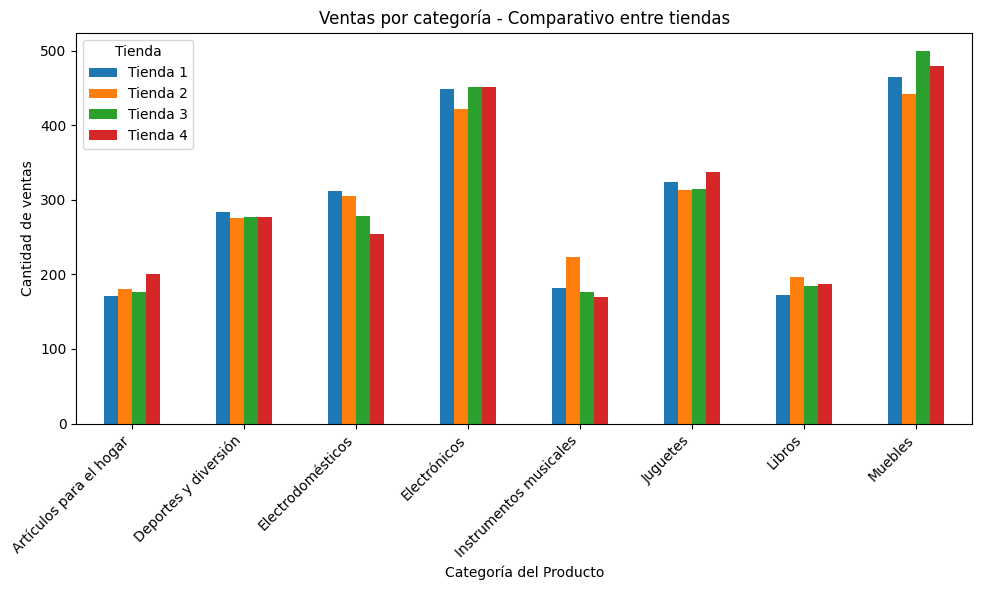

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

pivot = ventas_categoria.pivot(index="Categoría del Producto", columns="Tienda", values="Cantidad de ventas")

pivot.plot(kind="bar", figsize=(10,6))
plt.title("Ventas por categoría - Comparativo entre tiendas")
plt.xlabel("Categoría del Producto")
plt.ylabel("Cantidad de ventas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



# 3. Calificación promedio de la tienda


In [17]:
todas_tiendas["Calificación"] = pd.to_numeric(todas_tiendas["Calificación"], errors="coerce")

calificaciones_promedio = (
    todas_tiendas.groupby("Tienda")["Calificación"]
    .mean()
    .reset_index()
    .sort_values("Calificación", ascending=False)
)

pd.options.display.float_format = "{:.2f}".format
calificaciones_promedio


,Tienda,Calificación
2,Tienda 3,4.05
1,Tienda 2,4.04
3,Tienda 4,4.00
0,Tienda 1,3.98


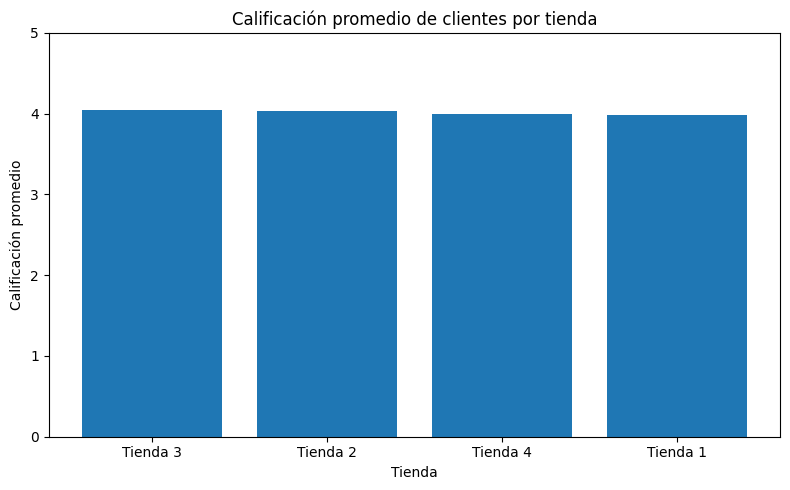

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(calificaciones_promedio["Tienda"], calificaciones_promedio["Calificación"])
plt.title("Calificación promedio de clientes por tienda")
plt.xlabel("Tienda")
plt.ylabel("Calificación promedio")
plt.ylim(0, 5)  # el rango de calificación va de 1 a 5
plt.tight_layout()
plt.show()


# 4. Productos más y menos vendidos

In [19]:
productos_ventas = (
    todas_tiendas.groupby(["Tienda", "Producto"])
    .size()
    .reset_index(name="Cantidad de ventas")
)

productos_ventas.sort_values(["Tienda", "Cantidad de ventas"], ascending=[True, False], inplace=True)

productos_ventas.head(10)


,Tienda,Producto,Cantidad de ventas
1,Tienda 1,Armario,60
33,Tienda 1,Microondas,60
48,Tienda 1,TV LED UHD 4K,60
40,Tienda 1,Secadora de ropa,58
9,Tienda 1,Bloques de construcción,56
32,Tienda 1,Mesa de noche,56
5,Tienda 1,Balón de baloncesto,55
8,Tienda 1,Bicicleta,54
23,Tienda 1,Impresora,54
39,Tienda 1,Refrigerador,54


In [20]:
productos_top_bottom = (
    productos_ventas.groupby("Tienda")
    .apply(lambda x: pd.DataFrame({
        "Más vendido": [x.loc[x["Cantidad de ventas"].idxmax(), "Producto"]],
        "Ventas Más vendido": [x["Cantidad de ventas"].max()],
        "Menos vendido": [x.loc[x["Cantidad de ventas"].idxmin(), "Producto"]],
        "Ventas Menos vendido": [x["Cantidad de ventas"].min()]
    }))
    .reset_index(drop=True)
)

productos_top_bottom


/tmp/ipython-input-697765323.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.DataFrame({


,Más vendido,Ventas Más vendido,Menos vendido,Ventas Menos vendido
0,Armario,60,Auriculares con micrófono,33
1,Iniciando en programación,65,Juego de mesa,32
2,Kit de bancas,57,Bloques de construcción,35
3,Cama box,62,Guitarra eléctrica,33


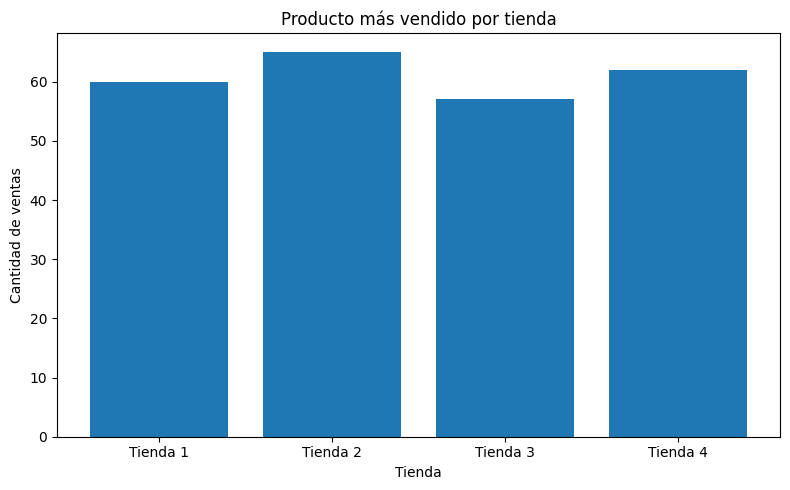

In [21]:
import matplotlib.pyplot as plt

top_productos = productos_ventas.groupby("Tienda").head(1)

plt.figure(figsize=(8,5))
plt.bar(top_productos["Tienda"], top_productos["Cantidad de ventas"])
plt.title("Producto más vendido por tienda")
plt.xlabel("Tienda")
plt.ylabel("Cantidad de ventas")
plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

In [22]:
todas_tiendas["Costo de envío"] = pd.to_numeric(todas_tiendas["Costo de envío"], errors="coerce")

envio_promedio = (
    todas_tiendas.groupby("Tienda")["Costo de envío"]
    .mean()
    .reset_index()
    .sort_values("Costo de envío", ascending=False)
)

# Mostrar tabla
pd.options.display.float_format = "{:,.2f}".format
envio_promedio


,Tienda,Costo de envío
0,Tienda 1,"26,018.61"
1,Tienda 2,"25,216.24"
2,Tienda 3,"24,805.68"
3,Tienda 4,"23,459.46"


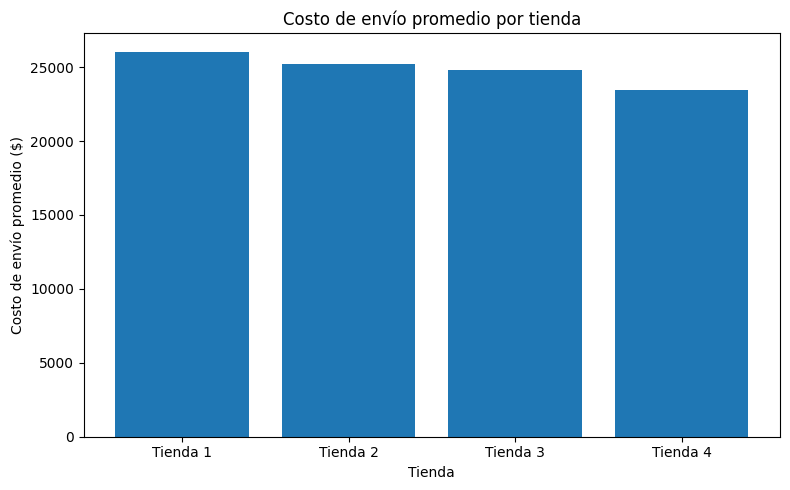

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(envio_promedio["Tienda"], envio_promedio["Costo de envío"])
plt.title("Costo de envío promedio por tienda")
plt.xlabel("Tienda")
plt.ylabel("Costo de envío promedio ($)")
plt.tight_layout()
plt.show()
